In [1]:
# ================================================================
#  SMART TENAGA — IoT FEED CLEANING + DIAGNOSTICS PIPELINE (v17)
# ================================================================
# Features:
# - Combines v16 modular OOP structure with v15's corrected CO₂
# - Vectorized interval energy, CO₂, sensor reset handling
# - Configurable lag & rolling features
# - Time-aware ML features: hour, day_of_week, is_weekend, month, day_of_month
# - Data validation, quality metrics, and logging
# - Comprehensive visual reporting
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import sys
from dataclasses import dataclass
from typing import Optional, Dict, Tuple, List
import warnings
warnings.filterwarnings('ignore')

# ================================================================
# CONFIGURATION & LOGGING
# ================================================================
@dataclass
class PipelineConfig:
    input_file: str = "D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/feeds.xlsx"
    output_file: str = "D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/feeds_cleaned.xlsx"
    emission_factor: float = 0.774  # kg CO2 per kWh
    time_gap_threshold: int = 120   # seconds
    suspicious_delta_kwh: float = 0.22  # kWh

    valid_ranges: Dict = None
    lag_periods: List[int] = None
    rolling_windows: List[int] = None

    source_timezone: str = 'UTC'
    target_timezone: str = 'Asia/Kuala_Lumpur'

    def __post_init__(self):
        if self.valid_ranges is None:
            self.valid_ranges = {
                "voltage": (140, 250),
                "current": (0, 20),
                "power": (0, 5000),
                "energy": (0, 1e6),
                "frequency": (45, 55),
                "power_factor": (0, 1.0)
            }
        if self.lag_periods is None:
            self.lag_periods = [1, 2, 3]
        if self.rolling_windows is None:
            self.rolling_windows = [3, 6]
# region logging setup
def setup_logging():
    logger = logging.getLogger('SmartTenaga')
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)
    try:
        file_handler = logging.FileHandler('scripts/pipeline_feeds_cleaned.log', encoding='utf-8')
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)
    except Exception as e:
        print(f"Warning: Could not create file handler: {e}")
    logger.propagate = False
    return logger

config = PipelineConfig()
logger = setup_logging()
#endregion

# ================================================================
# DATA LOADER
# ================================================================
class DataLoader:
    @staticmethod
    def load_data(filepath: str) -> pd.DataFrame:
        try:
            logger.info(f"Loading data from {filepath}")
            df = pd.read_excel(filepath)
            if df.empty:
                raise ValueError("Dataset is empty")
            logger.info(f"Loaded {len(df)} rows, {len(df.columns)} columns")
            return df
        except Exception as e:
            logger.error(f"Failed to load data: {e}")
            raise

    @staticmethod
    def validate_structure(df: pd.DataFrame) -> bool:
        required = ['created_at', 'voltage', 'current', 'power', 'energy']
        missing = [c for c in required if c not in df.columns]
        if missing:
            logger.error(f"Missing required columns: {missing}")
            return False
        return True

# ================================================================
# DATA CLEANER
# ================================================================
class DataCleaner:
    @staticmethod
    def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
        df = df.drop(columns=["entry_id","latitude","longitude","elevation","status.1"], errors='ignore')
        df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
        return df

    @staticmethod
    def format_datetime(df: pd.DataFrame) -> pd.DataFrame:
        df["created_at"] = pd.to_datetime(df["created_at"], errors='coerce')
        if df["created_at"].dt.tz is not None:
            df["created_at"] = df["created_at"].dt.tz_convert(config.target_timezone).dt.tz_localize(None)
        else:
            df["created_at"] = df["created_at"].dt.tz_localize(config.source_timezone)
            df["created_at"] = df["created_at"].dt.tz_convert(config.target_timezone).dt.tz_localize(None)
        df = df.sort_values("created_at").reset_index(drop=True)
        return df

    @staticmethod
    def enforce_numeric(df: pd.DataFrame) -> pd.DataFrame:
        num_cols = ["voltage","current","power","energy","frequency","power_factor"]
        for c in num_cols:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors='coerce')
        return df
    @staticmethod
    def fill_missing(df: pd.DataFrame, value: float = 0.0) -> pd.DataFrame:
        """
        Fill missing numeric values in the entire DataFrame.
        Can also be customized to handle categorical columns separately.
        """
        df = df.fillna(value)
        return df

# ================================================================
# DATA VALIDATOR
# ================================================================
class DataValidator:
    @staticmethod
    def drop_inactive_rows(df: pd.DataFrame) -> pd.DataFrame:
        power_cols = ['current','power','energy']
        active_mask = df['voltage'].notna() & (df['voltage']>0) | df[power_cols].fillna(0).ne(0).any(axis=1)
        return df[active_mask].copy()

    @staticmethod
    def filter_outliers(df: pd.DataFrame) -> pd.DataFrame:
        mask = pd.Series(True,index=df.index)
        for col,(low,high) in config.valid_ranges.items():
            if col in df.columns:
                mask &= df[col].between(low,high)
        return df[mask].copy()

    @staticmethod
    def calculate_data_quality_metrics(df: pd.DataFrame) -> Dict:
        metrics = {}

        metrics['total_records'] = len(df)
        metrics['time_coverage_days'] = (df['created_at'].max() - df['created_at'].min()).days
        metrics['avg_sampling_interval_seconds'] = df['time_diff_seconds'].mean()
        metrics['data_quality_score'] = df.notna().mean().mean()
        metrics['uptime_percentage'] = df['status'].mean()*100 if 'status' in df.columns else np.nan

        # Completeness per column
        completeness = df.notna().mean().to_dict()
        metrics['completeness'] = {col: f"{v:.2%}" for col, v in completeness.items()}

        # Optional: print nicely
        print("\nData Quality Metrics:")
        for key, value in metrics.items():
            print(f" - {key}: {value}")

        return metrics

 #region energy & co2 calculator   
# ================================================================
# ENERGY & CO2 CALCULATOR
# ================================================================
class EnergyCalculator:
    @staticmethod
    def compute_time_deltas(df: pd.DataFrame) -> pd.DataFrame:
        # FIRST sort and reset index to ensure proper sequence
        df = df.sort_values('created_at').reset_index(drop=True)
        
        # THEN calculate time differences
        df['time_diff_seconds'] = df['created_at'].diff().dt.total_seconds()
        df['time_diff_hours'] = df['time_diff_seconds'] / 3600
        
        # Fill first row
        df['time_diff_seconds'] = df['time_diff_seconds'].fillna(0)
        df['time_diff_hours'] = df['time_diff_hours'].fillna(0)
        
        # Gap flag
        df['gap_flag'] = (df['time_diff_seconds'] > config.time_gap_threshold).astype(int)
        
        return df

    @staticmethod
    def detect_energy_unit(df: pd.DataFrame) -> Tuple[pd.DataFrame,bool]:
        median_energy = df['energy'].median(skipna=True)
        median_power = df['power'].median(skipna=True)
        energy_in_kwh = True
        if median_energy > 100 and median_power < 2000:
            df['energy'] = df['energy']/1000.0
            energy_in_kwh = False
        return df, energy_in_kwh
    
    @staticmethod
    def compute_interval_energy_vectorized(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = df.sort_values('created_at').reset_index(drop=True)
        
        # --- Corrected CO2 ---
        df['co2_corrected'] = df['energy'] * config.emission_factor

        # --- IMPROVED: Handle missing data in energy difference ---
        energy_values = df['energy'].values
        energy_diffs = np.zeros(len(energy_values))
        
        # Find the last valid energy reading for each row
        last_valid_energy = energy_values[0]
        
        for i in range(1, len(energy_values)):
            current_energy = energy_values[i]
            
            # If current energy is 0 (missing data), carry forward the last valid
            if current_energy == 0:
                energy_diffs[i] = 0
            # If we have a valid energy reading, calculate diff from last valid
            elif current_energy > 0:
                if last_valid_energy > 0:  # Only calculate diff if we had a previous valid reading
                    energy_diffs[i] = current_energy - last_valid_energy
                last_valid_energy = current_energy
        
        df['energy_diff'] = energy_diffs

        # --- SIMPLE DEFAULT: Trust energy meter ---
        df['energy_increment_kwh'] = np.maximum(df['energy_diff'], 0)

        # --- SAFETY NET: Detect sensor resets (rare case) ---
        time_energy = (df['power'] * df['time_diff_hours']) / 1000
        sensor_reset = df['energy_diff'] < -0.1  # Large negative = reset
        
        # Only override if sensor reset detected
        df['energy_increment_kwh'] = np.where(
            sensor_reset,
            np.maximum(time_energy, 0),           # Use power-based for resets
            df['energy_increment_kwh']            # Otherwise keep simple approach
        )

        # --- Flag suspicious energy jumps ---
        #df['suspicious_delta'] = df['energy_increment_kwh'] > config.suspicious_delta_kwh

        # --- Drop old CO2 column if exists ---
        if 'co2' in df.columns:
            df = df.drop(columns=['co2'])

        return df

#region feature engineering
# ================================================================
# FEATURE ENGINEERING
# ================================================================
class FeatureEngineer:

    @staticmethod
    def categorize_power_factor(df: pd.DataFrame) -> pd.DataFrame:
        conditions = [
            df['power_factor'] < 0.6,
            df['power_factor'] < 0.8,
            df['power_factor'] <= 1.0
        ]
        choices = ['Low', 'Moderate', 'High']
        df['pf_category'] = np.select(conditions, choices, default='Unknown')
        return df


    # -----------------------------
    # Time features (including cyclical)
    # -----------------------------
    @staticmethod
    def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
        df['hour'] = df['created_at'].dt.hour
        df['day_of_week'] = df['created_at'].dt.dayofweek
        df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
        df['month'] = df['created_at'].dt.month
        df['day_of_month'] = df['created_at'].dt.day

        # Optional: cyclic transformations for better ML capture
        df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
        df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
        df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

        return df

    # -----------------------------
    # System status
    # -----------------------------
    @staticmethod
    def rebuild_system_status(df: pd.DataFrame) -> pd.DataFrame:
        df['status'] = np.where((df['voltage'].isna()) | (df['voltage']==0), 0, 1)
        return df
#endregion

# ================================================================
# PIPELINE ORCHESTRATOR
# ================================================================
class SmartTenagaPipelineV17:
    def __init__(self, config: PipelineConfig):
        self.config = config
        self.df_raw = None
        self.df_processed = None

    def run(self) -> pd.DataFrame:
        self.df_raw = DataLoader.load_data(self.config.input_file)
        if not DataLoader.validate_structure(self.df_raw):
            raise ValueError("Data structure invalid")
        df = DataCleaner.clean_columns(self.df_raw)
        df = DataCleaner.format_datetime(df)
        df = DataCleaner.enforce_numeric(df)
        df = df.sort_values('created_at').reset_index(drop=True)
        df = EnergyCalculator.compute_time_deltas(df)
        df, _ = EnergyCalculator.detect_energy_unit(df)
        df = EnergyCalculator.compute_interval_energy_vectorized(df)
        df = DataValidator.drop_inactive_rows(df)  
        df = DataValidator.filter_outliers(df)
        df = df.sort_values('created_at').reset_index(drop=True)
        df = EnergyCalculator.compute_time_deltas(df)
        df = FeatureEngineer.categorize_power_factor(df)
        df = FeatureEngineer.create_time_features(df)
        df = FeatureEngineer.rebuild_system_status(df)
        df = DataCleaner.fill_missing(df, value=0)

        #metrics = DataValidator.calculate_data_quality_metrics(df)
        #logger.info(f"Data quality metrics: {metrics}")

        # Save cleaned dataset
        df.to_excel(self.config.output_file, index=False)
        logger.info(f"Saved cleaned dataset to {self.config.output_file}")
        self.df_processed = df
        return df

# ================================================================
# EXECUTION
# ================================================================
def main():
    pipeline = SmartTenagaPipelineV17(config)
    final_df = pipeline.run()
    return final_df

if __name__ == "__main__":
    df_final = main()


2025-11-15 22:20:45,785 - INFO - Loading data from D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/feeds.xlsx
2025-11-15 22:20:47,945 - INFO - Loaded 14279 rows, 14 columns
2025-11-15 22:20:53,818 - INFO - Saved cleaned dataset to D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/feeds_cleaned.xlsx


In [2]:
import pandas as pd
import sys

sys.path.append("D:/PythonLibs")

# Load datalog
datalog = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/datalog.xlsx')

# Convert timestamps and remove timezone
datalog['start_time'] = pd.to_datetime(datalog['start_time']).dt.tz_localize(None)
datalog['end_time'] = pd.to_datetime(datalog['end_time']).dt.tz_localize(None)

# Fill missing deviceType with empty string
datalog['deviceType'] = datalog['deviceType'].fillna('')

# Device code to name mapping
device_map = {
    'a': 'laptop',
    'b': 'phone',
    'c': 'lamp',
    'd': 'ipad',
    'e': 'monitor',
    'f': 'powerbank',
    'g': 'dryer',
    'h': 'earbuds'
}

# Sort codes alphabetically and remove extra spaces
datalog['deviceType'] = datalog['deviceType'].apply(
    lambda x: ','.join(sorted([i.strip() for i in x.split(',') if i.strip() != '']))
)

# Create new columns for each device with 1=yes, 0=no
for code, name in device_map.items():
    datalog[name] = datalog['deviceType'].apply(lambda x: 1 if code in x.split(',') else 0)
    
# Add column for total devices active
datalog['total_devices'] = datalog[list(device_map.values())].sum(axis=1)

# ===============================
# Create binary activity column
# ===============================
datalog['is_active'] = datalog[list(device_map.values())].sum(axis=1) > 0
datalog['is_active'] = datalog['is_active'].astype(int)  # 1=active, 0=non-active

# Drop unnecessary columns
for col in ['comment','comment2','data_status']:
    if col in datalog.columns:
        datalog = datalog.drop(columns=[col])

# Save cleaned and expanded datalog
datalog.to_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/datalog_cleaned.xlsx', index=False)

print("Datalog cleaning complete! Device columns now use 1/0 and binary 'is_active' column added.")



Datalog cleaning complete! Device columns now use 1/0 and binary 'is_active' column added.


In [3]:
import pandas as pd

# Load dataset
df = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/merged_feeds_datalog.xlsx')

# Convert timestamp
df['created_at'] = pd.to_datetime(df['created_at'])

# Round timestamps to nearest minute
df['minute'] = df['created_at'].dt.floor('min')

# Define aggregation
agg_dict = {
    'voltage': 'mean',
    'current': 'mean',
    'power': 'mean',
    'energy': 'last',
    'energy_increment_kwh': 'sum',  # <-- sum increments within the same minute
    'energy_diff': 'sum',
    # 'co2_corrected': 'sum',
    'frequency': 'mean',
    'power_factor': 'mean',
    'status': 'max',
    'total_devices': 'max',
    'is_active': 'max',
    # Devices
    'laptop': 'max',
    'phone': 'max',
    'lamp': 'max',
    'ipad': 'max',
    'monitor': 'max',
    'powerbank': 'max',
    'dryer': 'max',
    'earbuds': 'max',

}

# Group by rounded minute and aggregate
df_minute = df.groupby('minute', as_index=False).agg(agg_dict)

# Rename minute column to created_at for consistency
df_minute.rename(columns={'minute':'created_at'}, inplace=True)

# Inspect a few rows
print(df_minute[['created_at']].head(20))

print("Original total kWh:", df['energy_increment_kwh'].sum())
print("Minute-level total kWh:", df_minute['energy_increment_kwh'].sum())

# Save the minute-level dataset
df_minute.to_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/merged_feeds_minute_level_accumulated.xlsx', index=False)
print("Saved minute-level accumulated dataset.")

#

            created_at
0  2025-09-24 19:37:00
1  2025-09-24 19:38:00
2  2025-09-24 19:39:00
3  2025-09-24 19:40:00
4  2025-09-24 19:41:00
5  2025-09-24 19:42:00
6  2025-09-24 19:43:00
7  2025-09-24 19:44:00
8  2025-09-24 19:45:00
9  2025-09-24 19:46:00
10 2025-09-24 19:47:00
11 2025-09-24 19:48:00
12 2025-09-24 20:12:00
13 2025-09-24 20:13:00
14 2025-09-24 20:14:00
15 2025-09-24 20:15:00
16 2025-09-24 20:16:00
17 2025-09-24 20:17:00
18 2025-09-24 20:18:00
19 2025-09-24 20:19:00
Original total kWh: 4.257
Minute-level total kWh: 4.257
Saved minute-level accumulated dataset.


In [4]:
import pandas as pd
import numpy as np

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/merged_feeds_minute_level_accumulated.xlsx')
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# ---------------------------
# Drop CO2 columns
# ---------------------------
df = df.drop(['co2','co2_corrected'], axis=1, errors='ignore')

# ---------------------------
# Power factor category + encoded
# ---------------------------
def categorize_power_factor(df):
    conditions = [
        df['power_factor'] < 0.6,
        df['power_factor'] < 0.8,
        df['power_factor'] <= 1.0
    ]
    choices = ['Low', 'Moderate', 'High']
    df['pf_category'] = np.select(conditions, choices, default='Unknown')
    return df

df = categorize_power_factor(df)
df['pf_encoded'] = df['pf_category'].map({'Low':0,'Moderate':1,'High':2}).fillna(0).astype(int)
df = df.drop(['pf_category'], axis=1, errors='ignore')

# ---------------------------
# Time gaps (minutes) + gap flag
# ---------------------------
df['time_diff_min'] = df['created_at'].diff().dt.total_seconds().div(60).fillna(0)
TIME_GAP_THRESHOLD_MIN = 2  # example: flag gaps > 2 minutes
df['gap_flag'] = (df['time_diff_min'] > TIME_GAP_THRESHOLD_MIN).astype(int)

# ---------------------------
# Device columns
# ---------------------------
DEVICE_COLUMNS = ['laptop','phone','lamp','ipad','monitor','powerbank','dryer','earbuds']
HIGH_POWER_DEVICES = ['laptop','dryer','monitor','ipad']
LOW_POWER_DEVICES = [dev for dev in DEVICE_COLUMNS if dev not in HIGH_POWER_DEVICES]

# ---------------------------
# High-Power Logs
# ---------------------------
for dev in HIGH_POWER_DEVICES:
    if dev in df.columns:
        df[f'{dev}_log'] = np.log1p(df[dev]*df['power'])

ROLLING_MINUTES = [5,10,20]
df_indexed = df.set_index('created_at')
for window in ROLLING_MINUTES:
    cols = [f'{dev}_log' for dev in HIGH_POWER_DEVICES if f'{dev}_log' in df.columns]
    if cols:
        df[f'High_Power_Log_{window}min'] = df_indexed[cols].rolling(f'{window}min').mean().sum(axis=1).values

# ---------------------------
# Low power total
# ---------------------------
if LOW_POWER_DEVICES:
    df['Low_Power_Total'] = df[LOW_POWER_DEVICES].multiply(df['power'], axis=0).sum(axis=1)

# ---------------------------
# Energy active flag
# ---------------------------
df['energy_active'] = (df['energy_increment_kwh'] > 0).astype(int)  # New feature: energy event

# ---------------------------
# Dynamic lags (1–5)
# ---------------------------
lag_cols = ['power','energy_increment_kwh','Low_Power_Total'] + [f'High_Power_Log_{w}min' for w in ROLLING_MINUTES]
for col in lag_cols:
    for lag in [1, 2, 3, 5, 10]:
        df[f'{col}_lag{lag}'] = df[col].shift(lag).fillna(0)

# ---------------------------
# Rolling statistics
# ---------------------------
rolling_cols = ['power','energy_increment_kwh']
rolling_windows = [3, 5, 10]
for col in rolling_cols:
    for window in rolling_windows:
        df[f'{col}_rolling_mean_{window}'] = df[col].rolling(window).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].rolling(window).std().fillna(0)

# ---------------------------
# Log-transform and interaction features
# ---------------------------
df['energy_log'] = np.log1p(df['energy_increment_kwh'])
if 'total_devices' in df.columns:
    df['power_total_interaction'] = df['power'] * df['total_devices']

# ---------------------------
# Drop initial rows with lag/rolling artifacts
# ---------------------------
# df = df.iloc[12:].reset_index(drop=True)  # removes first 12 minutes with mostly zeros in rolling/lags

# Fill lag/rolling NaNs instead of dropping rows
lag_rolling_cols = [col for col in df.columns if '_lag' in col or 'rolling' in col]
df[lag_rolling_cols] = df[lag_rolling_cols].fillna(0)

# ---------------------------
# Additional Enrichment Features
# ---------------------------

# Rate of change
df['delta_power'] = df['power'].diff().fillna(0)
df['delta_voltage'] = df['voltage'].diff().fillna(0)
df['delta_energy'] = df['energy_increment_kwh'].diff().fillna(0)

# Apparent power and efficiency
df['apparent_power'] = df['voltage'] * df['current']
df['pf_efficiency'] = df['power'] / df['apparent_power'].replace(0, np.nan)

# Daily cumulative energy
df['date'] = df['created_at'].dt.date
df['daily_energy_sum'] = df.groupby('date')['energy_increment_kwh'].cumsum()

# # ---------------------------
# # Fill missing values
# # ---------------------------
# df = df.fillna(0)

# ---------------------------
# De-fragment DataFrame
# ---------------------------
df = df.copy()

# ---------------------------
# Save ML-ready dataset
# ---------------------------
df.to_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min3.xlsx', index=False)
print("ML preprocessing complete. Dataset saved as ml_ready_dataset_min2.xlsx")


ML preprocessing complete. Dataset saved as ml_ready_dataset_min2.xlsx


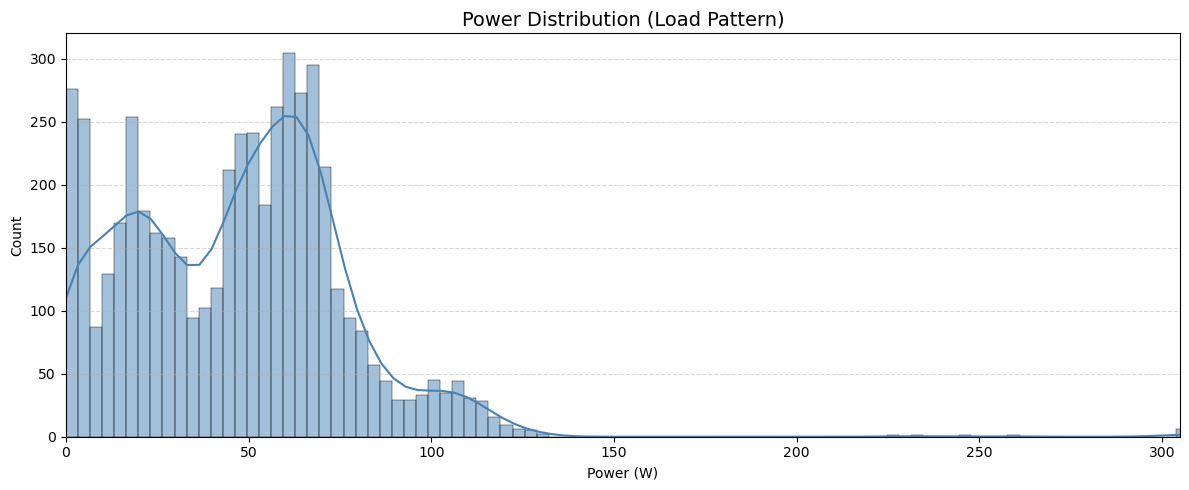

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

sns.histplot(df['power'], bins=200, kde=True, color='steelblue')

plt.title("Power Distribution (Load Pattern)", fontsize=14)
plt.xlabel("Power (W)")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.xlim(0, df['power'].quantile(0.995))  # limit extreme outliers, focus on real loads

plt.tight_layout()
plt.show()
